
# Кейс спринта


В этом кейсе вы будете работать с данными «Карты ДТП» — некоммерческого проекта, посвящённого проблеме дорожно-транспортных происшествий в России. Вы могли знакомиться с этим проектом в Песочнице прошлого спринта.

Заказчик предлагает продолжить исследование данных и изучить взаимосвязи. Особенно заказчика интересует, с чем может быть связана аварийность на дорогах.

## Что нужно сделать
Выполнить предобработку для удобства работы с данными: выбрать оптимальные названия столбцов и типы данных. Вам также понадобится дать ответы на вопросы заказчика.

Если вы не работали с прошлой Песочницей, то всё равно можете выполнить этот проект. Для удобства советуем изменить названия столбцов датафрейма, используя код ниже:

```
import pandas as pd

df = pd.read_csv('путь до папки с файлами/Kirovskaya_oblast.csv')
df.columns = [c.replace('properties.', '') for c in df.columns]

```


### Вопросы заказчика

1. Как распределено количество участников ДТП и почему? Встречаются ли аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Для числа участников найдите наиболее типичное значение. По желанию можете проверить распределения и других столбцов.

2. Предположите, между какими столбцами в датасете `Kirovskaya_oblast.csv` высокая корреляция. Проверьте своё предположение.  

3. Как связаны категории аварий и погодные условия?

4. Постройте процентную разбивку аварий по видам освещённости. При этом учитывайте пол участника и сделайте расчёты для мужчин и женщин отдельно.

5. Исследуйте, чем отличаются аварии без пострадавших от тех, в которых был один пострадавший или более.

6. Сделайте общий вывод о связи аварийности с другими факторами. Какие рекомендации вы можете дать заказчику?

## Описание данных

Датасет `Kirovskaya_oblast.csv` содержит информацию о ДТП в Кировской области:

* `geometry.coordinates` — координаты ДТП;

* `id` — идентификатор ДТП;

* `properties.tags` — тег происшествия;

* `properties.light` — освещённость;

* `properties.point.lat` — широта;

* `properties.point.long` — долгота;

* `properties.nearby` — ближайшие объекты;

* `properties.region` — регион;

* `properties.scheme` — схема ДТП;

* `properties.address` — ближайший адрес;

* `properties.weather` — погода;

* `properties.category` — категория ДТП;

* `properties.datetime` — дата и время ДТП;

* `properties.injured_count` — число пострадавших;

* `properties.parent_region` — область;

* `properties.road_conditions` — состояние покрытия;

* `properties.participants_count` — число участников;

* `properties.participant_categories` — категории участников.

`Kirovskaya_oblast_participiants.csv` хранит сведения об участниках:

* `role` — роль;

* `gender` — пол;

* `violations` — какие правила дорожного движения были нарушены конкретным участником;

* `health_status` — состояние здоровья после ДТП;

* `years_of_driving_experience` — число лет опыта;

* `id` — идентификатор ДТП.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/datasets/Kirovskaya_oblast.csv')
df.columns = [c.replace("properties.", "") for c in df.columns]

### 1. Как распределено количество участников ДТП и почему? Встречаются ли аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Для числа участников найдите наиболее типичное значение. По желанию можете проверить распределения и других столбцов.

In [ ]:
df['participants_count'].value_counts()

,count
participants_count,
2,8611
3,2929
1,1533
4,909
5,353
6,109
7,44
8,9
9,9


In [ ]:
df['participants_count'].describe()

,participants_count
count,14517.000000
mean,2.355721
std,1.004847
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,30.000000


Встречается авария с 30 участниками, которая выбивается из общего количества. Остальные числа пострадавших кажутся вполне вероятными.

Отвечая на вопрос о распределении, можно использовать разные методы анализа. Мы воспользовались `describe()` и `value_counts()`. Ниже примеры с построением гистограммы и «ящика с усами».

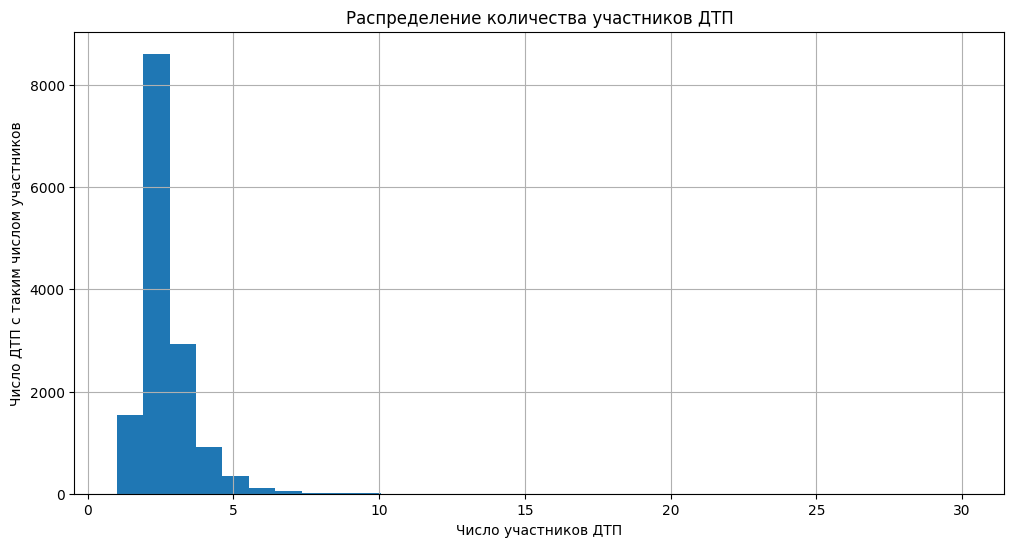

In [ ]:
import matplotlib.pyplot as plt


ax = df['participants_count'].hist(figsize=(12, 6), bins = 32)
ax.set_title('Распределение количества участников ДТП')
ax.set_xlabel('Число участников ДТП')
ax.set_ylabel('Число ДТП с таким числом участников');

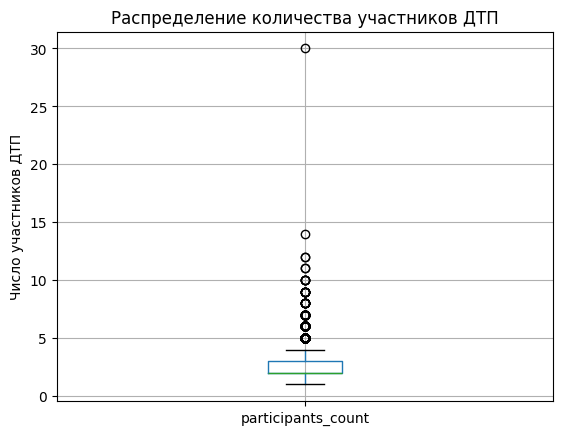

In [ ]:
ax = df.boxplot(column='participants_count')
ax.set_title('Распределение количества участников ДТП')
ax.set_ylabel('Число участников ДТП');

Попробуем ответить на вопрос, почему получилось такое распределение. Можно рассуждать так: один из наиболее частых видов ДТП — столкновение, в котором два участника. Наезд на пешехода тоже предполагает двоих участников.

> В подобных случаях стоит проверять данные, если это возможно. Важно, чтобы предположения, которые вы делаете, согласовывались с данными.


В ячейке ниже приведён способ проверить число пострадавших в наиболее популярных категориях аварий.

In [ ]:
df.query('category in ["Наезд на пешехода", "Столкновение"]')['participants_count'].value_counts()

,count
participants_count,
2,6205
3,2368
4,752
5,304
6,97
7,39
8,7
9,6
10,5


### 2. Предположите,  между какими столбцами в данных высокая корреляция? Проверьте своё предположение.  

Обнаруживаем сильную корреляцию между числом пострадавших и числом участников аварии.

In [ ]:
df.corr(numeric_only=True)

,id,point.lat,point.long,scheme,injured_count,participants_count
id,1.000000,0.044838,0.000309,-0.033493,-0.001796,-0.011355
point.lat,0.044838,1.000000,0.004421,0.022883,-0.029886,-0.000820
point.long,0.000309,0.004421,1.000000,0.021997,-0.005333,-0.008409
scheme,-0.033493,0.022883,0.021997,1.000000,-0.213594,-0.396280
injured_count,-0.001796,-0.029886,-0.005333,-0.213594,1.000000,0.727196
participants_count,-0.011355,-0.000820,-0.008409,-0.396280,0.727196,1.000000


<Axes: >

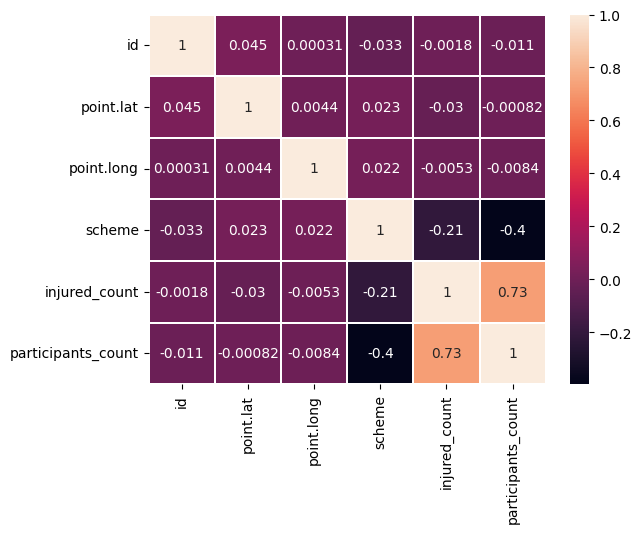

In [ ]:
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True), linewidth=0.1, annot=True)

Число пострадавших и участников аварии действительно скоррелированы. В других столбцах и не ожидалось увидеть сильную корреляцию. Однако привлекают внимание два значения: корреляция `-0.21` между числом пострадавших и номером схемы, `-0.4` между числом участников и номером схемы. Вероятно, номер схемы может быть связан с числом участников и пострадавших.

### 3. Как связаны категории аварий и погодные условия?

In [ ]:
df.groupby(['weather', 'category'])['id'].nunique().sort_values()

weather                category                                                                                     
['Пасмурно']           Падение груза                                                                                       1
['Снегопад']           Наезд на лицо, не являющееся участником дорожного движения, осуществляющее производство работ       1
['Пасмурно', 'Дождь']  Отбрасывание предмета                                                                               1
                       Падение пассажира                                                                                   1
['Снегопад']           Наезд на животное                                                                                   1
                                                                                                                        ... 
['Ясно']               Съезд с дороги                                                                                    586
                       Наезд на пешехода                                                                                1572
['Пасмурно']           Наезд на пешехода                                                                                2268
['Ясно']               Столкновение                                                                                     2288
['Пасмурно']           Столкновение                                                                                     2514
Name: id, Length: 115, dtype: int64

Встречаются строки, в которых указан целый список различных погодных явлений. В таком случае можно посмотреть на общее число ДТП по категориям.

In [ ]:
df['category'].value_counts()

,count
category,
Столкновение,5423
Наезд на пешехода,4364
Съезд с дороги,1155
Опрокидывание,1002
Падение пассажира,738
Наезд на препятствие,667
Наезд на велосипедиста,589
Наезд на стоящее ТС,312
Иной вид ДТП,129


В датафрейме всего 14517 ДТП. Можно рассмотреть 96–98% всех аварий: взять топ-7 популярных ДТП и посмотреть, как эти категории распределены по разным погодным условиям. Так мы проанализируем большую часть данных, а остальные категории рассматривать не будем.

In [ ]:
for category_name in df['category'].value_counts().head(7).index:
  display(df.query('category == @category_name').groupby(['weather', 'category'])['id'].nunique().sort_values(ascending = False))

,,id
weather,category,
['Пасмурно'],Столкновение,2514
['Ясно'],Столкновение,2288
['Снегопад'],Столкновение,274
['Дождь'],Столкновение,205
"['Пасмурно', 'Снегопад']",Столкновение,47
"['Ясно', 'Температура выше +30С']",Столкновение,34
"['Пасмурно', 'Дождь']",Столкновение,21
['Метель'],Столкновение,14
"['Снегопад', 'Метель']",Столкновение,8


,,id
weather,category,
['Пасмурно'],Наезд на пешехода,2268
['Ясно'],Наезд на пешехода,1572
['Дождь'],Наезд на пешехода,220
['Снегопад'],Наезд на пешехода,200
"['Пасмурно', 'Дождь']",Наезд на пешехода,36
"['Пасмурно', 'Снегопад']",Наезд на пешехода,27
"['Ясно', 'Температура выше +30С']",Наезд на пешехода,14
['Метель'],Наезд на пешехода,9
['Туман'],Наезд на пешехода,6


,,id
weather,category,
['Ясно'],Съезд с дороги,586
['Пасмурно'],Съезд с дороги,431
['Дождь'],Съезд с дороги,51
['Снегопад'],Съезд с дороги,50
"['Пасмурно', 'Снегопад']",Съезд с дороги,13
"['Пасмурно', 'Дождь']",Съезд с дороги,10
"['Ясно', 'Температура выше +30С']",Съезд с дороги,6
['Метель'],Съезд с дороги,2
['Туман'],Съезд с дороги,2


,,id
weather,category,
['Ясно'],Опрокидывание,532
['Пасмурно'],Опрокидывание,367
['Дождь'],Опрокидывание,40
['Снегопад'],Опрокидывание,27
"['Пасмурно', 'Снегопад']",Опрокидывание,13
"['Пасмурно', 'Дождь']",Опрокидывание,12
['Туман'],Опрокидывание,3
"['Ясно', 'Температура выше +30С']",Опрокидывание,3
['Метель'],Опрокидывание,2


,,id
weather,category,
['Пасмурно'],Падение пассажира,390
['Ясно'],Падение пассажира,315
['Дождь'],Падение пассажира,18
['Снегопад'],Падение пассажира,8
"['Пасмурно', 'Снегопад']",Падение пассажира,2
"['Пасмурно', 'Дождь']",Падение пассажира,1
"['Пасмурно', 'Температура ниже -30С']",Падение пассажира,1
"['Ясно', 'Температура выше +30С']",Падение пассажира,1
"['Ясно', 'Температура ниже -30С']",Падение пассажира,1


,,id
weather,category,
['Ясно'],Наезд на препятствие,304
['Пасмурно'],Наезд на препятствие,300
['Дождь'],Наезд на препятствие,26
['Снегопад'],Наезд на препятствие,24
"['Пасмурно', 'Снегопад']",Наезд на препятствие,4
"['Ясно', 'Температура выше +30С']",Наезд на препятствие,4
"['Пасмурно', 'Дождь']",Наезд на препятствие,2
['Туман'],Наезд на препятствие,2
"['Ясно', 'Температура ниже -30С']",Наезд на препятствие,1


,,id
weather,category,
['Ясно'],Наезд на велосипедиста,397
['Пасмурно'],Наезд на велосипедиста,171
['Дождь'],Наезд на велосипедиста,17
"['Ясно', 'Температура выше +30С']",Наезд на велосипедиста,2
"['Пасмурно', 'Дождь']",Наезд на велосипедиста,1
['Снегопад'],Наезд на велосипедиста,1


Рассмотрим первые две категории, которые включают 60% ДТП. Здесь видны как сходства, так и различия. К примеру, большее число ДТП каждого из видов произошло в пасмурную погоду — это кажется довольно логичным. А разница в числе ДТП с наездом в пасмурные и ясные дни отличается от разницы ДТП со столкновением в тех же погодных условиях. Возможно, при ясной погоде пешеходов замечают лучше, чем другую машину. Причину этой тенденции можно предположить в том, что при столкновении двух машин скорость сближения выше, чем при столкновении пешехода и машины.

На третьем и четвёртом месте по популярности расположились категории, в которых наиболее популярной погода была «Ясно».

### 4. Постройте процентную разбивку аварий по видам освещённости. При этом учитывайте пол участника и сделайте расчёты для мужчин и женщин отдельно.

Задания от заказчиков могут быть сформулированы не слишком очевидно. Здесь нужно учитывать всех участников аварий или только водителей? Мы будем изучать водителей:

In [ ]:
df_partipiants = pd.read_csv('/content/drive/MyDrive/datasets/Kirovskaya_oblast_participiants.csv')

Важно проверить, не встречается ли в данных дубликатов. Узнаем, есть ли водители, которые указаны в данных несколько раз.

In [ ]:
df_partipiants.query('role == "Водитель"')['id'].value_counts()

,count
id,
1985567,6
2649405,6
1984910,6
1984276,6
2889522,5
...,...
2795031,1
2754524,1
1988533,1


Оказалось, что такие водители есть. Избавимся от дубликатов.

In [ ]:
df_partipiants = df_partipiants.query('role == "Водитель"')
df_partipiants = df_partipiants.drop_duplicates(subset = 'id')

In [ ]:
df_res = df_partipiants.merge(df, on = 'id')

In [ ]:
df_percent = df_res.groupby(['gender', 'light'])['id'].nunique().reset_index().sort_values('light')
df_percent['prcnt'] = 100*df_percent['id'] / ([df_res.query('gender == "Женский"')['id'].nunique(), df_res.query('gender == "Мужской"')['id'].nunique()] * 5)

Конструкция выглядит сложно, но такой код даст нужный результат.

In [ ]:
df_percent.sort_values(['gender', 'prcnt'], ascending = False)

,gender,light,id,prcnt
8,Мужской,Светлое время суток,6905,63.658154
5,Мужской,"В темное время суток, освещение включено",2372,21.867798
7,Мужской,"В темное время суток, освещение отсутствует",1067,9.836821
9,Мужской,Сумерки,339,3.125288
6,Мужской,"В темное время суток, освещение не включено",164,1.511939
3,Женский,Светлое время суток,1096,64.243845
0,Женский,"В темное время суток, освещение включено",376,22.039859
2,Женский,"В темное время суток, освещение отсутствует",168,9.847597
4,Женский,Сумерки,48,2.813599
1,Женский,"В темное время суток, освещение не включено",18,1.055100


Видим близкие относительные значения вне зависимости от пола. При этом для обоих полов характерно наибольшее число аварий в светлое время суток. В будущем интересно выяснить, какая характерная освещённость будет в разных городах.

### 5. Исследуйте, чем отличаются аварии без пострадавших от тех, в которых был один пострадавший или более.

Первое предположение — попробовать решить задание, взяв ДТП, в которых `injured_count == 0`. Однако таких аварий в данных не оказалось.

Однако в данных есть столбец `health_status`, и на него можно опираться при оценке пострадавших. Также стоит обсудить с заказчиком, почему `injured_count` не согласуется с `health_status`.

In [ ]:
df_res['injured_count'].value_counts()

,count
injured_count,
1,10445
2,1711
3,540
4,212
5,72
6,26
7,10
8,4
9,2


Проще сохранить `id` аварий с пострадавшими, так как в аварии может быть несколько участников и сложнее проверить, что не все из них пострадали.

In [ ]:
ids_injured = df_res.query('health_status != "Не пострадал"')['id'].unique()

In [ ]:
df.head()

,geometry.coordinates,id,tags,light,point.lat,point.long,nearby,region,scheme,address,weather,category,datetime,injured_count,parent_region,road_conditions,participants_count,participant_categories
0,"[47.875603, 57.24379]",1983180,Дорожно-транспортные происшествия,Светлое время суток,57.243790,47.875603,[],Яранский район,600.0,Р-176 Вятка Чебоксары - Йошкар-Ола - Киров - С...,['Дождь'],Опрокидывание,2017-07-01 18:00:00,1,Кировская область,['Мокрое'],3,['Все участники']
1,"[47.87903, 57.304807]",2889433,Дорожно-транспортные происшествия,Светлое время суток,57.304807,47.879030,"['Административные здания', 'Нерегулируемый пе...",Яранский район,710.0,"г Яранск, ул Кирова, 10",['Ясно'],Наезд на пешехода,2023-09-12 17:10:00,1,Кировская область,"['Сухое', 'Отсутствие, плохая различимость гор...",2,"['Все участники', 'Пешеходы']"
2,"[47.840781, 57.297156]",2591208,Дорожно-транспортные происшествия,Сумерки,57.297156,47.840781,"['Жилые дома индивидуальной застройки', 'Нерег...",Яранский район,NaN,"г Яранск, ул Чапаева, 80",['Пасмурно'],Съезд с дороги,2021-07-02 21:25:00,1,Кировская область,['Мокрое'],1,['Все участники']
3,"[47.834365, 57.244775]",2577639,Дорожно-транспортные происшествия,Светлое время суток,57.244775,47.834365,['Жилые дома индивидуальной застройки'],Яранский район,200.0,"м Знаменка, ул Кирова, 15",['Пасмурно'],Столкновение,2021-05-31 18:55:00,1,Кировская область,['Сухое'],2,"['Все участники', 'Мотоциклисты']"
4,"[47.968197, 57.357738]",1981026,Дорожно-транспортные происшествия,Светлое время суток,57.357738,47.968197,['Нерегулируемый перекрёсток неравнозначных ул...,Яранский район,NaN,"с/п Никольское, Киров-Советск- Яранск - подъез...",['Ясно'],Опрокидывание,2018-05-16 16:25:00,2,Кировская область,"['Сухое', 'Отсутствие, плохая различимость гор...",2,['Все участники']


In [ ]:
df.columns

Index(['geometry.coordinates', 'id', 'tags', 'light', 'point.lat',
       'point.long', 'nearby', 'region', 'scheme', 'address', 'weather',
       'category', 'datetime', 'injured_count', 'parent_region',
       'road_conditions', 'participants_count', 'participant_categories'],
      dtype='object')

При такой формулировке можно решать задание по-разному. Пройдёмся по столбцам с признаками ДТП, которые могут повлиять на `health_status`, и проверим, будет ли разница.

Действия при этом будут похожи, поэтому осуществим некоторую автоматизацию. Сначала выведем разбивку по разным типам ДТП с пострадавшими, а ниже разбивку по ДТП без пострадавших.

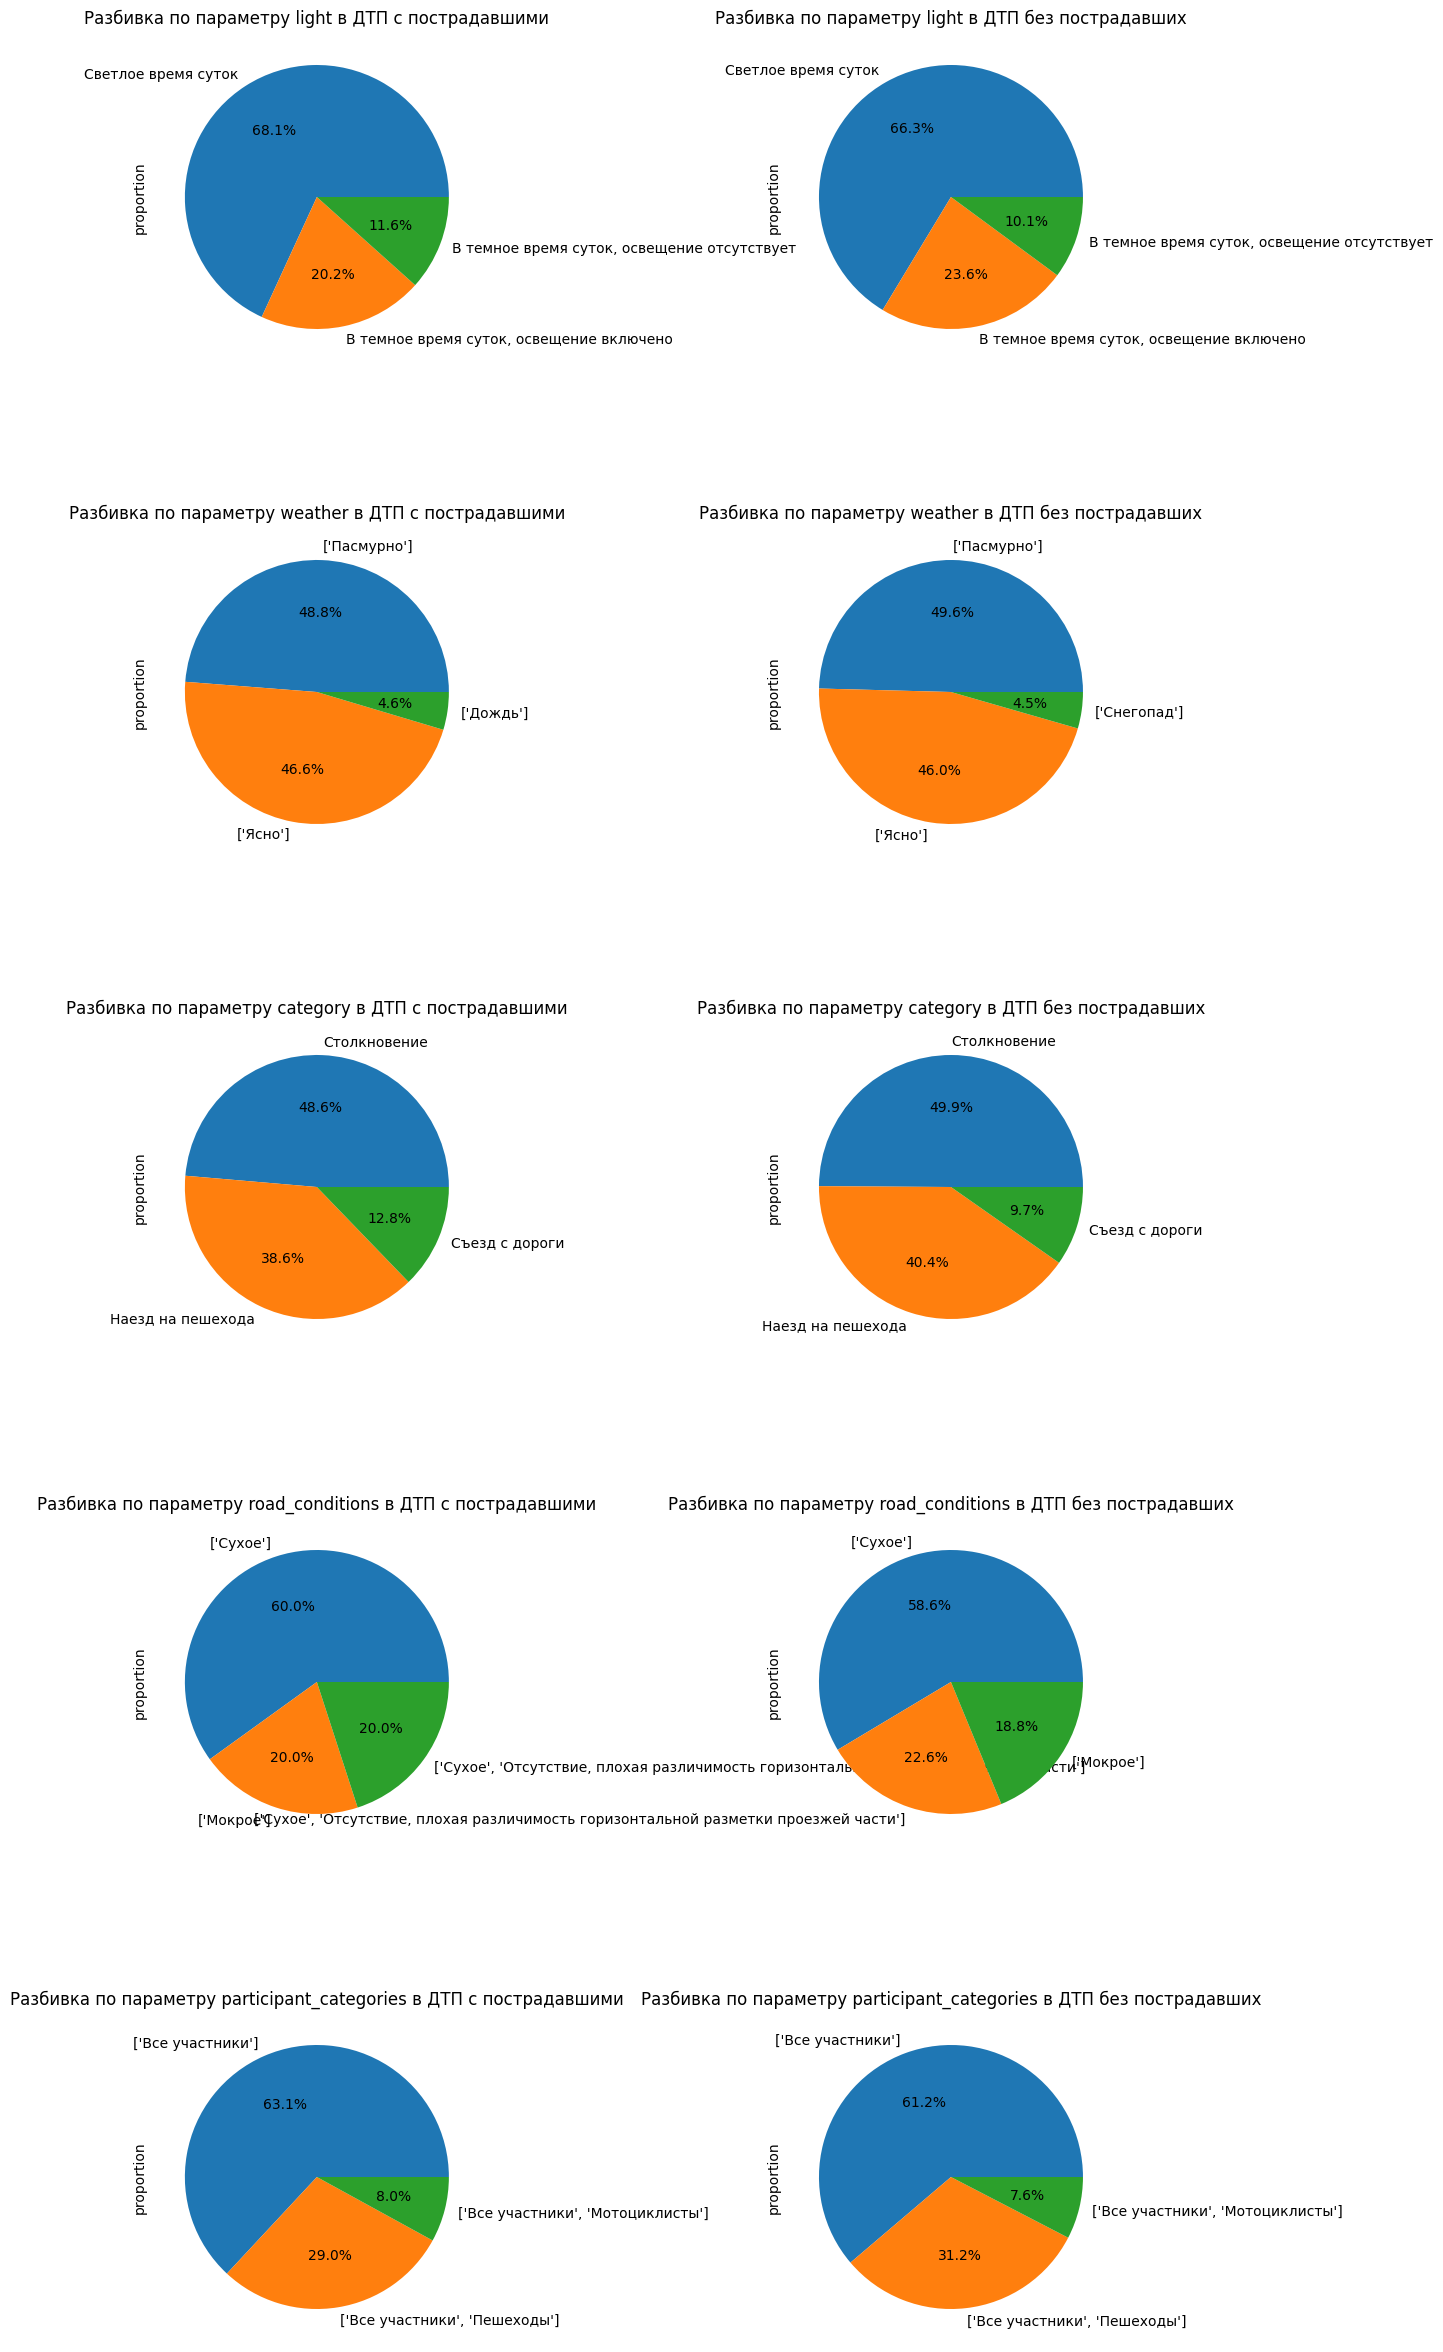

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=5, ncols=2,  figsize=(15, 30))
plt.subplots_adjust(wspace=0.2, hspace=0.5)

counter = 0
for column_name in ['light', 'weather', 'category', 'road_conditions', 'participant_categories']:
  df_injured = df.query('id in @ids_injured')[column_name].value_counts(normalize = True).reset_index()[0:3]
  df_no_injured = df.query('id not in @ids_injured')[column_name].value_counts(normalize = True).reset_index()[0:3]

  df_injured.plot.pie(ax=axes[counter, 0], y='proportion', autopct='%1.1f%%', labels= df_injured[column_name], legend=False)
  axes[counter, 0].title.set_text(f'Разбивка по параметру {column_name} в ДТП с пострадавшими')

  df_no_injured.plot.pie(ax=axes[counter, 1],y='proportion', autopct='%1.1f%%', labels= df_no_injured[column_name], legend=False)
  axes[counter, 1].title.set_text(f'Разбивка по параметру {column_name} в ДТП без пострадавших')

  counter += 1


Мы рассмотрели несколько признаков, и по ним не видно различий в относительных долях ДТП с пострадавшими и без.

На визуализации в разбивке по `road_conditions` подписи секторов оказались длинными, и их стоит сократить. Пример реализации ниже.

In [ ]:
df['road_conditions'].replace("['Сухое', 'Отсутствие, плохая различимость горизонтальной разметки проезжей части']",
                              "['Сухое', 'Разметка не различима']").value_counts()

,count
road_conditions,
['Сухое'],4135
"['Сухое', 'Разметка не различима']",1534
['Мокрое'],1342
['Обработанное противогололедными материалами'],886
['Заснеженное'],647
...,...
"['Обработанное противогололедными материалами', 'Недостатки зимнего содержания', 'Отсутствие дорожных знаков в необходимых местах', 'Неправильное применение, плохая видимость дорожных знаков']",1
"['Неисправность светофора', 'Мокрое', 'Дефекты покрытия', 'Отсутствие дорожных знаков в необходимых местах', 'Отсутствие пешеходных ограждений в необходимых местах']",1
"['Мокрое', 'Отсутствие временных ТСОД в местах проведения работ']",1


### 6. Сделайте общий вывод о связи аварийности с другими факторами. Какие рекомендации вы можете дать заказчику?

В кратком виде выводы могут выглядеть подобным образом:

1. Самые распространённые аварии — столкновение и наезд на пешехода — происходят при пасмурной погоде. Разрыв в числе столкновений при ясной и пасмурной погоде несущественный, однако наезды на пешеходов при ясной погоде происходят реже. Возможно, при столкновении двух машин скорость сближения выше, чем при столкновении пешехода и машины. Стоит также отметить, что съезд с дороги, опрокидывания и наезды на препятствия случались чаще в ясную погоду.

2. В разбивке по полам и освещённости различий не обнаружено. Также похожи значения топ-3 для разных признаков ДТП в зависимости от наличия пострадавших.

3. Обнаружено, что наиболее распространённое количество пострадавших в авариях — 2. Это может быть связано с самыми частыми типами аварий — «столкновение» и «наезд на пешехода».

4. В данных встречается ДТП с 30 участниками.

5. В датасете число пострадавших в `injured_count` не согласуется с `health_status`. Стоит узнать у заказчика, почему так произошло.
